# Customer Segmentation using K-Means Clustering and PCA

**Name:** Aditya Shukla

**Registration Number:** 23BAI10155

**Application Number:** IN26011099

**Batch Number:** 1(A)

**Email ID:** aditya.23bai10155@vitbhopal.ac.in

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
categorical_features = ['Gender']

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Categorical Features: ['Gender']


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
print("Missing values:\n", df.isnull().sum())

df = df.drop(columns=['CustomerID'])

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)

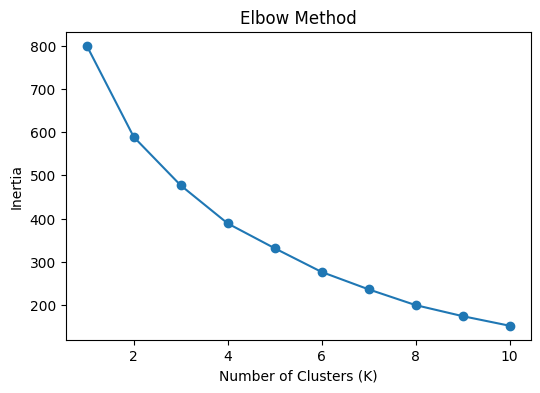

In [ ]:
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'].value_counts()

Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance captured by 2 components:", pca.explained_variance_ratio_.sum())

Explained variance ratio per component: [0.33690046 0.26230645]
Total variance captured by 2 components: 0.5992069019819846


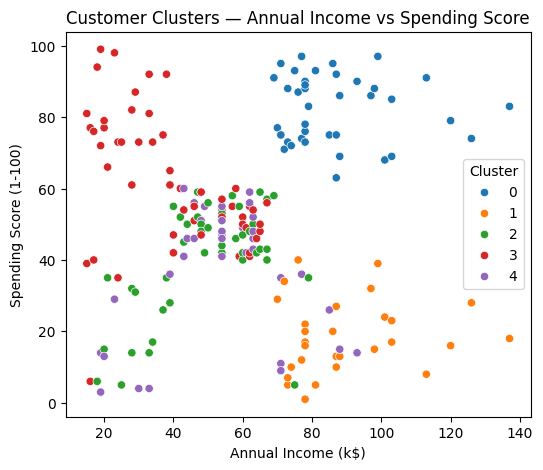

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='tab10')
plt.title('Customer Clusters — Annual Income vs Spending Score')
plt.show()

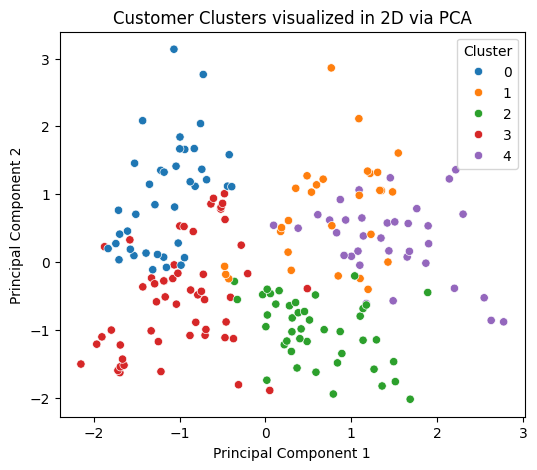

In [ ]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='tab10')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Clusters visualized in 2D via PCA')
plt.show()

In [12]:
print("--- Observations ---")
print("1. The elbow curve flattens out around K=5 -> adding more clusters beyond this gives diminishing reductions in inertia, so 5 is a reasonable trade-off between simplicity and fit.")
print(f"2. The 2 principal components capture about {pca.explained_variance_ratio_.sum()*100:.1f}% of the total variance -> the PCA plot is a useful approximation of the cluster structure, not a perfect one, since some spread is lost in the compression.")
print("3. The Annual Income vs Spending Score plot shows the classic pattern: distinct groups such as high-income/low-spending, high-income/high-spending, and low-income/high-spending customers, each a natural marketing segment.")
print("4. The PCA-based plot and the Income-vs-Spending plot broadly agree on the overall grouping, which is a reasonable sanity check even though PCA is working with less than the full variance.")

--- Observations ---
1. The elbow curve flattens out around K=5 -> adding more clusters beyond this gives diminishing reductions in inertia, so 5 is a reasonable trade-off between simplicity and fit.
2. The 2 principal components capture about 59.9% of the total variance -> the PCA plot is a useful approximation of the cluster structure, not a perfect one, since some spread is lost in the compression.
3. The Annual Income vs Spending Score plot shows the classic pattern: distinct groups such as high-income/low-spending, high-income/high-spending, and low-income/high-spending customers, each a natural marketing segment.
4. The PCA-based plot and the Income-vs-Spending plot broadly agree on the overall grouping, which is a reasonable sanity check even though PCA is working with less than the full variance.


## Conclusion

This project applied K-Means clustering to segment mall customers based on their age, gender, annual income, and spending score, using the Elbow Method to justify K=5 as the number of clusters. The resulting groups map cleanly onto real marketing personas, for example high-income big spenders versus high-income conservative spenders, giving the mall's management concrete segments to target with different campaigns (e.g. loyalty perks for high-value customers, promotions to nudge low-spending high-income customers toward more purchases). Principal Component Analysis was used to compress the four standardized features into two components purely for visualization, letting the cluster structure be plotted and inspected even though the clustering itself happened in the original higher-dimensional space. A key limitation of K-Means is that it requires the number of clusters to be chosen in advance and assumes roughly spherical, similarly sized clusters, so it can perform poorly on data with irregularly shaped or overlapping groups. A key advantage of PCA is that it makes high-dimensional data interpretable and visualizable in 2D or 3D without needing to pick just two original features and ignore the rest.